In [46]:
import pandas as pd
import yfinance as yf 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import scipy
import lxml
import requests
from io import StringIO

<h1><center> Pull NASDAQ-100 Stock and Metadata Info from Wikipedia </center></h1>

In [47]:
# Import Nasdaq tickers from wikipedia

url = 'https://en.wikipedia.org/wiki/Nasdaq-100'
headers = {'User-Agent': 'Mozilla/5.0 (compatible; stock-analysis/1.0)'}
response = requests.get(url, headers = headers)
response.raise_for_status()

tables = pd.read_html(StringIO(response.text))
nasdaq100 = tables[5]
tickers = nasdaq100['Ticker'].to_list()

In [48]:
def get_nasdaq_100_at_date(target_date: str):
    """ 
    Fetches NASDAQ 100 Wikipedia data as of the target date using the Wikipedia
    revision history API. Returns tickers and revision ID.
    """

    api_url = 'https://en.wikipedia.org/w/api.php'
    headers = {'User-Agent': 'Mozilla/5.0(compatible: stock-analysis/ 1.0)'}

    # Find the closest revision to target date
    params = {
        'action': 'query',
        'titles': 'Nasdaq-100',  # correct article title (case-sensitive after first char)
        'prop': 'revisions',
        'rvprop': 'ids|timestamp',
        'rvstart': f'{target_date}T23:59:59Z',
        'rvdir': 'older',
        'rvlimit': 1,
        'format': 'json'
    }

    rev_data = requests.get(api_url, params=params, headers=headers).json()
    page = next(iter(rev_data['query']['pages'].values()))
    rev = page['revisions'][0] 
    rev_id, timestamp = rev['revid'], rev['timestamp']
    print(f'Historical Snapshot -> revision {rev_id} ({timestamp})')

    # Fetch HTML data for the specific revision
    html_url = f'https://en.wikipedia.org/w/index.php?title=Nasdaq-100&oldid={rev_id}'
    response = requests.get(html_url, headers=headers)
    tables = pd.read_html(StringIO(response.text))

    # Find the components table — column name varies across revisions
    ticker_col_candidates = ['Ticker', 'Symbol']
    for t in tables:
        for col in ticker_col_candidates:
            if col in t.columns:
                return t[col].tolist(), rev_id
    raise ValueError('Ticker table not found in historical revision - check the table index')


In [49]:
def build_survivorship_universe(current_tickers: list, start_date: str):
    """ 
    Diffs current vs historical Nasdaq-100 composition. Returns full
    universe + per-ticker status labels.
    """

    historical_tickers, _ = get_nasdaq_100_at_date(start_date)

    current_set = set(current_tickers)
    historical_set = set(historical_tickers)

    removed = historical_set - current_set # Survivorship bias candidates
    added = current_set - historical_set # New entrants since start date
    stable = current_set & historical_set

    print(f'\n--- Constituency  Changes ({start_date} -> today)---')
    print(f'Stable : {len(stable)}')
    print(f'Added : {len(added)} {sorted(added)}')
    print(f'Removed : {len(removed)} {sorted(removed)}')
    print(f'Full Universe : {len(historical_set | current_set)} ')

    status_map = (
        {t: 'current' for t in stable} |
        {t: 'added' for t in added} |
        {t: 'removed' for t in removed}
    )

    full_universe = sorted(historical_set | current_set)
    return full_universe, status_map, removed, added


ANALYSIS_START = '2026-01-01'
full_universe, status_map, removed_tickers, added_tickers = build_survivorship_universe(tickers, ANALYSIS_START)

Historical Snapshot -> revision 1330682349 (2026-01-01T21:48:52Z)

--- Constituency  Changes (2026-01-01 -> today)---
Stable : 98
Added : 3 ['LITE', 'SNDK', 'WMT']
Removed : 3 ['AZN', 'CSGP', 'TEAM']
Full Universe : 104 


In [50]:
print(tickers)

['ADBE', 'AMD', 'ABNB', 'ALNY', 'GOOGL', 'GOOG', 'AMZN', 'AEP', 'AMGN', 'ADI', 'AAPL', 'AMAT', 'APP', 'ARM', 'ASML', 'ADSK', 'ADP', 'AXON', 'BKR', 'BKNG', 'AVGO', 'CDNS', 'CHTR', 'CTAS', 'CSCO', 'CCEP', 'CTSH', 'CMCSA', 'CEG', 'CPRT', 'COST', 'CRWD', 'CSX', 'DDOG', 'DXCM', 'FANG', 'DASH', 'EA', 'EXC', 'FAST', 'FER', 'FTNT', 'GEHC', 'GILD', 'HON', 'IDXX', 'INSM', 'INTC', 'INTU', 'ISRG', 'KDP', 'KLAC', 'KHC', 'LRCX', 'LIN', 'LITE', 'MAR', 'MRVL', 'MELI', 'META', 'MCHP', 'MU', 'MSFT', 'MSTR', 'MDLZ', 'MPWR', 'MNST', 'NFLX', 'NVDA', 'NXPI', 'ORLY', 'ODFL', 'PCAR', 'PLTR', 'PANW', 'PAYX', 'PYPL', 'PDD', 'PEP', 'QCOM', 'REGN', 'ROP', 'ROST', 'SNDK', 'STX', 'SHOP', 'SBUX', 'SNPS', 'TMUS', 'TTWO', 'TSLA', 'TXN', 'TRI', 'VRSK', 'VRTX', 'WMT', 'WBD', 'WDC', 'WDAY', 'XEL', 'ZS']


In [51]:
# Download NASDAQ-100 from y-finance
nasdaq_100 = yf.download(
    tickers = full_universe,
    start = ANALYSIS_START,
    interval = '1d',
    auto_adjust = True
)['Close']

nasdaq_100 = round(nasdaq_100, 2)
print(f'Price Matrix: {nasdaq_100.shape} ({nasdaq_100.shape[1]} tickers x {nasdaq_100.shape[0]} days)')

[*********************100%***********************]  104 of 104 completed


Price Matrix: (98, 104) (104 tickers x 98 days)


In [52]:
# Pull metadata for NASDAQ-100 companies
records = []

for ticker in full_universe:
    try:
        info = yf.Ticker(ticker).info
        records.append({
            'ticker': ticker,
            'name': info.get('shortName'),
            'sector': info.get('sector'),
            'market_cap': info.get('marketCap'),
            'pe_ratio': info.get('trailingPE'),
            'beta': info.get('beta'),
            'status': status_map.get(ticker, 'current')
        })
    except Exception as e:
        print(f'Failed for {ticker}: {e}')
        records.append({ 
            'ticker': ticker, 
            'name': None, 
            'sector': None,
            'market_cap': None, 
            'pe_ratio': None, 
            'beta': None,
            'status': status_map.get(ticker, 'unknown')
            
            })

records = pd.DataFrame(records, columns = ([
                                            'ticker',
                                            'name',
                                            'sector',
                                            'market_cap',
                                            'pe_ratio',
                                            'beta',
                                            'status'
]))

records['status'].value_counts()



status
current    98
removed     3
added       3
Name: count, dtype: int64

In [53]:
records

,ticker,name,sector,market_cap,pe_ratio,beta,status
0,AAPL,Apple Inc.,Technology,4535749181440,37.432728,1.065,current
1,ABNB,"Airbnb, Inc.",Consumer Cyclical,78550376448,32.679012,1.208,current
2,ADBE,Adobe Inc.,Technology,98931990528,14.263403,1.417,current
3,ADI,"Analog Devices, Inc.",Technology,193407647744,59.175858,1.194,current
4,ADP,"Automatic Data Processing, Inc.",Technology,90064125952,21.017723,0.841,current
...,...,...,...,...,...,...,...
99,WDAY,"Workday, Inc.",Technology,31994705920,39.795030,1.035,current
100,WDC,Western Digital Corporation,Technology,166922665984,28.981450,2.158,current
101,WMT,Walmart Inc.,Consumer Defensive,958671028224,42.348590,0.652,added
102,XEL,Xcel Energy Inc.,Utilities,50615779328,23.365995,0.421,current


In [54]:
nasdaq_100

Ticker,AAPL,ABNB,ADBE,ADI,ADP,ADSK,AEP,ALNY,AMAT,AMD,...,TTWO,TXN,VRSK,VRTX,WBD,WDAY,WDC,WMT,XEL,ZS
2026-01-02,270.51,133.01,333.30,272.89,250.81,286.73,114.07,400.17,268.20,223.47,...,251.60,175.48,220.46,452.13,28.51,205.79,187.61,112.31,74.13,220.57
2026-01-05,266.76,135.87,331.56,276.42,255.21,288.66,112.36,397.83,283.61,221.08,...,257.31,175.13,220.14,448.80,28.53,208.90,187.79,112.26,73.53,222.76
2026-01-06,261.87,138.02,335.99,292.03,258.98,293.17,113.31,406.40,295.27,214.35,...,254.35,189.89,220.67,468.38,28.47,210.30,219.28,113.89,73.88,222.03
2026-01-07,259.85,137.04,338.10,291.98,259.12,293.79,111.99,422.50,291.47,210.02,...,256.67,183.57,219.06,484.15,28.59,211.14,199.78,112.27,72.68,231.16
2026-01-08,258.56,138.66,339.04,298.23,263.49,276.58,114.19,399.40,280.94,204.68,...,252.38,186.28,222.29,469.68,28.32,209.79,187.59,112.62,72.84,220.32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-18,297.84,134.30,255.64,418.58,222.94,243.49,127.68,286.27,413.06,420.99,...,242.16,300.60,171.52,436.58,27.10,128.88,458.68,133.34,78.10,174.69
2026-05-19,298.97,131.16,254.99,414.31,220.44,244.16,128.92,294.30,406.40,414.05,...,238.14,302.31,170.71,434.31,27.09,129.34,455.80,134.20,79.73,175.25
2026-05-20,302.25,135.55,253.37,398.05,220.69,243.63,128.87,298.48,426.32,447.58,...,236.62,304.88,170.66,430.44,27.42,126.61,459.62,130.85,79.86,174.45
2026-05-21,304.99,134.25,244.10,384.21,220.08,240.19,129.61,300.51,427.36,449.59,...,238.08,298.39,171.60,433.54,27.10,121.85,486.46,121.34,80.20,171.01


<h1><center> Build NASDAQ-100 Market benchmark </center></h1>

In [55]:
return_nasdaq_100 = nasdaq_100.pct_change().dropna()

In [56]:
# Create a random set of weights for portfolio

def give_weights():
    rand = np.random.random(len(nasdaq_100.columns))
    rand /= rand.sum()
    return rand

In [57]:
print(give_weights().sum()*100)

100.0


In [58]:
pf_exp, pf_stds, weights = [], [], []

for i in range(10000):
    W = give_weights()
    weights.append(W)
    daily_returns = np.dot(return_nasdaq_100, W)
    pf_exp.append(daily_returns.mean()* 252)
    pf_stds.append(daily_returns.std()* np.sqrt(252))

In [59]:
simulated_port = pd.DataFrame({'pf_exp': pf_exp, 
                               'pf_stds': pf_stds,
                               'weights': weights})

In [60]:
simulated_port

,pf_exp,pf_stds,weights
0,0.377219,0.169434,"[0.015539389479403889, 0.017913198915929015, 0..."
1,0.270353,0.162689,"[0.015008707727168377, 0.0011557219835667226, ..."
2,0.382966,0.169636,"[0.00893456205401077, 0.00649011819011425, 0.0..."
3,0.487532,0.176630,"[0.011377849772269832, 0.018943748929222383, 0..."
4,0.275932,0.155391,"[0.015388342756865745, 0.011159033816495356, 0..."
...,...,...,...
9995,0.387733,0.151191,"[0.011820352684959748, 0.0027315835984281266, ..."
9996,0.464533,0.169604,"[0.017411245203513025, 0.0017374823384680121, ..."
9997,0.397711,0.162883,"[0.001978340663124113, 0.001504732644703308, 0..."
9998,0.403423,0.157329,"[0.004191482887102231, 0.0026866060494491447, ..."


<Axes: title={'center': 'Efficient Frontier - Monte Carlo Simulation'}, xlabel='Annualized Volatility', ylabel='Annualized return'>

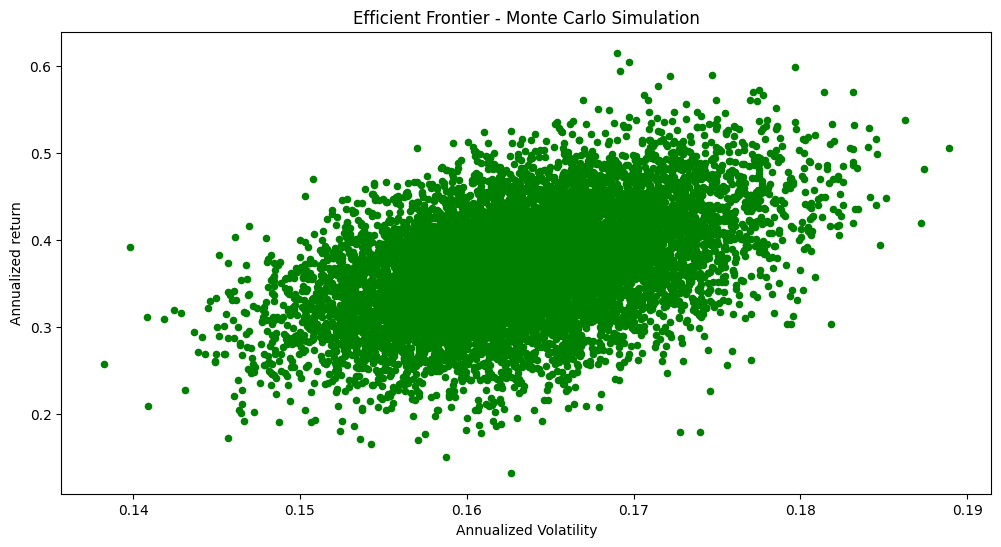

In [61]:
simulated_port.plot(x = 'pf_stds', 
               y = 'pf_exp', 
               kind = 'scatter', 
               color = 'green',
               figsize = (12, 6),
               title = 'Efficient Frontier - Monte Carlo Simulation',
               xlabel = 'Annualized Volatility',
               ylabel = 'Annualized return' 
               )


In [62]:
# Calculate sharpe ratio
risk_free_rate = 0.043 # Risk free rate

# Use risk free rate to calculate sharpe ratio
shp_ratio_rf = (simulated_port['pf_exp'] - risk_free_rate)/simulated_port['pf_stds']
best_idx = shp_ratio_rf.idxmax()
best_portfolio = simulated_port.loc[best_idx]
optimal_weights = np.array(best_portfolio['weights'])

print('Optimal Portfolio - Max Sharpe')
print(f'Annualized Return: {best_portfolio['pf_exp']:.2%}')
print(f'Annualized Volume: {best_portfolio['pf_stds']:.2%}')
print(f'Sharpe Ratio (rf): {shp_ratio_rf[best_idx]:.4f}')



Optimal Portfolio - Max Sharpe
Annualized Return: 61.54%
Annualized Volume: 16.90%
Sharpe Ratio (rf): 3.3876


In [63]:
# Import D-wave stock data
qbts = yf.download('QBTS', ANALYSIS_START, interval='1d', auto_adjust=True)['Close']
qbts = qbts.squeeze()

# Align to the same trading days as our price matrix
common_idx = nasdaq_100.index.intersection(qbts.index)
nasdaq_aligned = nasdaq_100.loc[common_idx]
qbts_aligned = qbts.loc[common_idx]

return_nasdaq_aligned = nasdaq_aligned.pct_change().dropna()
return_qbts = qbts_aligned.pct_change().dropna()

# Realign after drop na
common_return_idx = return_nasdaq_aligned.index.intersection(return_qbts.index)
return_nasdaq_aligned = return_nasdaq_aligned.loc[common_return_idx]
return_qbts = return_qbts.loc[common_return_idx]

print(f'QBTS price range: {qbts_aligned.index[0].date()} -> {qbts_aligned.index[-1].date()}')
print(f'Overlapping trading days: {len(common_return_idx)}')

[*********************100%***********************]  1 of 1 completed

QBTS price range: 2026-01-02 -> 2026-05-22
Overlapping trading days: 97


In [64]:
"""Compute daily portfolio returns using optimal weights 
    Weights are built using the full 104 day ticker universe
"""

portfolio_daily_return = return_nasdaq_aligned.dot(optimal_weights)

# Cumulative returns (dollar growth of $1 invested)
cumulative_portfolio = ( 1 + portfolio_daily_return).cumprod()
cumulative_qbts = ( 1+ return_qbts).cumprod()


In [65]:
# Performance Tear sheet

def tearsheet(name, daily_return, rf=risk_free_rate):
    annual_return = daily_return.mean() * 252
    annual_volume = daily_return.std() * np.sqrt(252)
    sharpe = (annual_return- rf)/ annual_volume
    cumulative = (1 + daily_return).cumprod()
    rolling_max = cumulative.cummax()
    drawdown = (cumulative - rolling_max) / rolling_max
    max_drawdown = drawdown.min()
    calmar_ratio = annual_return / abs(max_drawdown) if max_drawdown != 0 else np.nan
    total_return = cumulative.iloc[-1] -1

    print(f'\n {'-'*40}')
    print(f'{name}')
    print(f'{'-'*40}')
    print(f'Total Return: {total_return:.2%}')
    print(f'Annual Return: {annual_return:.2%}')
    print(f'Annual Volume: {annual_volume:.2%}')
    print(f'Sharpe Ratio (risk free rate = 4.3%): {sharpe}')
    print(f'Max Drawdown: {max_drawdown:.2%}')
    print(f'Calmar Ratio : {calmar_ratio:.4f}')
    
    return {'name': name,
            'total_return': total_return,
            'annual_return': annual_return,
            'annual_volume': annual_volume,
            'sharpe': sharpe,
            'max_drawdown': max_drawdown,
            'calmar_ratio': calmar_ratio
            }

stats_portfolio = tearsheet('OptimalNASDAQ Portfolio(Max Sharpe)', portfolio_daily_return)
stats_qbts = tearsheet('QBTS (D-Wave Quantum)', return_qbts)

# Correlation
correlation = portfolio_daily_return.corr(return_qbts)
print(f'\n Return Correlation (Portfolio versus QBTS): {correlation:.4f}')


 ----------------------------------------
OptimalNASDAQ Portfolio(Max Sharpe)
----------------------------------------
Total Return: 26.00%
Annual Return: 61.54%
Annual Volume: 16.99%
Sharpe Ratio (risk free rate = 4.3%): 3.3700758514973757
Max Drawdown: -6.56%
Calmar Ratio : 9.3763

 ----------------------------------------
QBTS (D-Wave Quantum)
----------------------------------------
Total Return: 4.51%
Annual Return: 70.12%
Annual Volume: 112.51%
Sharpe Ratio (risk free rate = 4.3%): 0.5850175707564117
Max Drawdown: -58.49%
Calmar Ratio : 1.1988

 Return Correlation (Portfolio versus QBTS): 0.5143


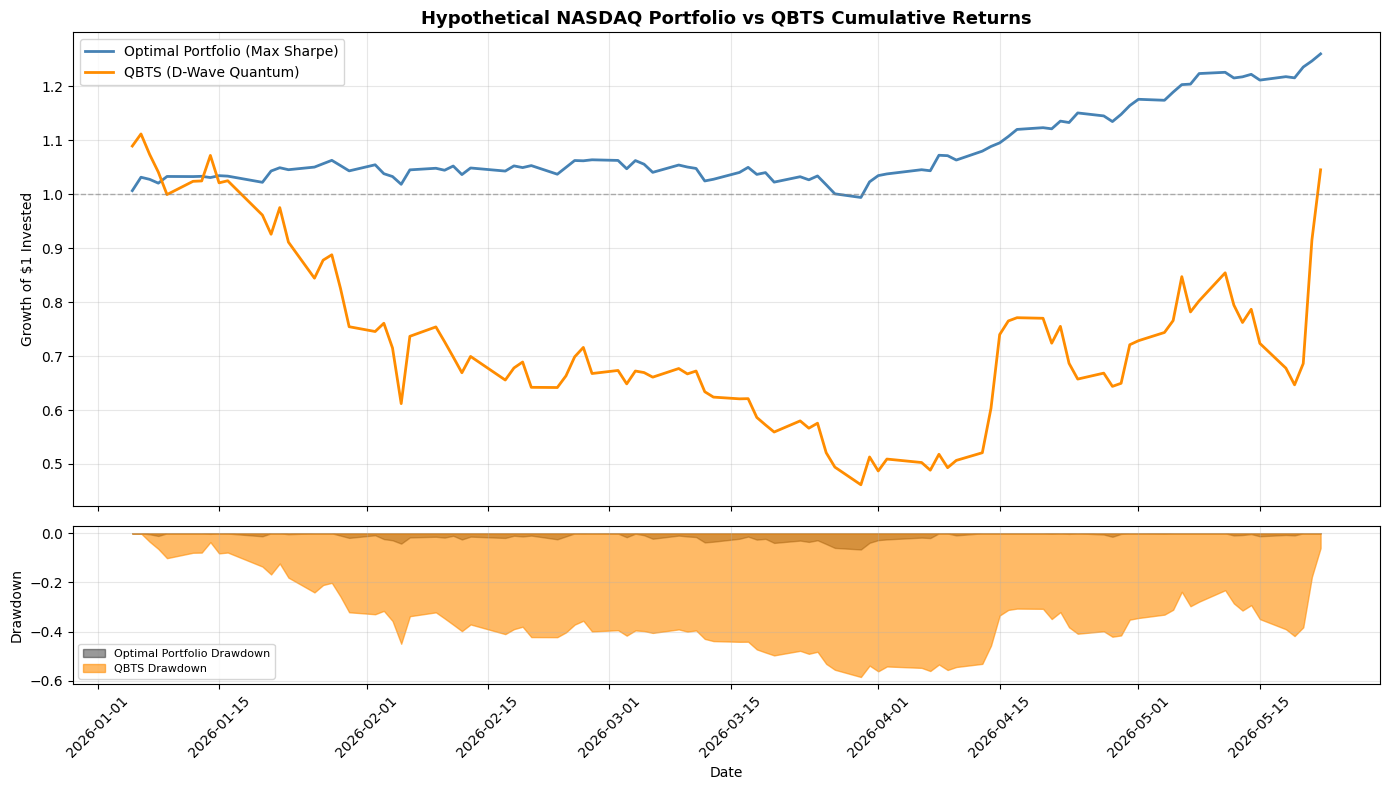

In [68]:
# Visualize cumulative returns and drawdowns
fig, axes = plt.subplots(2, 1, 
                         figsize = (14, 8), 
                         sharex = True, 
                         gridspec_kw = {'height_ratios': (3, 1)})

# Cumulative returns plot
ax1 = axes[0]
ax1.plot(cumulative_portfolio.index,
        cumulative_portfolio.values, 
        label = 'Optimal Portfolio (Max Sharpe)',
        color = 'steelblue',
        linewidth = 2)

ax1.plot(cumulative_qbts.index,
         cumulative_qbts.values,
         label = 'QBTS (D-Wave Quantum)',
         color = 'darkorange',
         linewidth = 2)

ax1.axhline(1, color = 'gray',
             linestyle = '--', 
             linewidth = 1, 
             alpha = 0.6)

ax1.set_ylabel('Growth of $1 Invested')
ax1.set_title('Hypothetical NASDAQ Portfolio vs QBTS Cumulative Returns', 
              fontsize = 13, 
              fontweight = 'bold')

ax1.legend()
ax1.grid(True, 
         alpha =0.3)

# Drawdown plot
ax2 = axes[1]
portfolio_drawdown = (cumulative_portfolio - cumulative_portfolio.cummax()) / cumulative_portfolio.cummax()
qbts_drawdown = (cumulative_qbts - cumulative_qbts.cummax()) / cumulative_qbts.cummax()
ax2.fill_between(portfolio_drawdown.index, 
                 portfolio_drawdown.values,
                 0, 
                 alpha = 0.4,
                 color = 'black',
                 label = 'Optimal Portfolio Drawdown') 
                 
ax2.fill_between(qbts_drawdown.index,
                 qbts_drawdown.values,
                 0,
                 alpha =0.6,
                 color = 'darkorange',
                 label = 'QBTS Drawdown')

ax2.set_ylabel('Drawdown')
ax2.set_xlabel('Date')
plt.xticks(rotation = 45)
ax2.legend(fontsize = 8)
ax2.grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()
                 




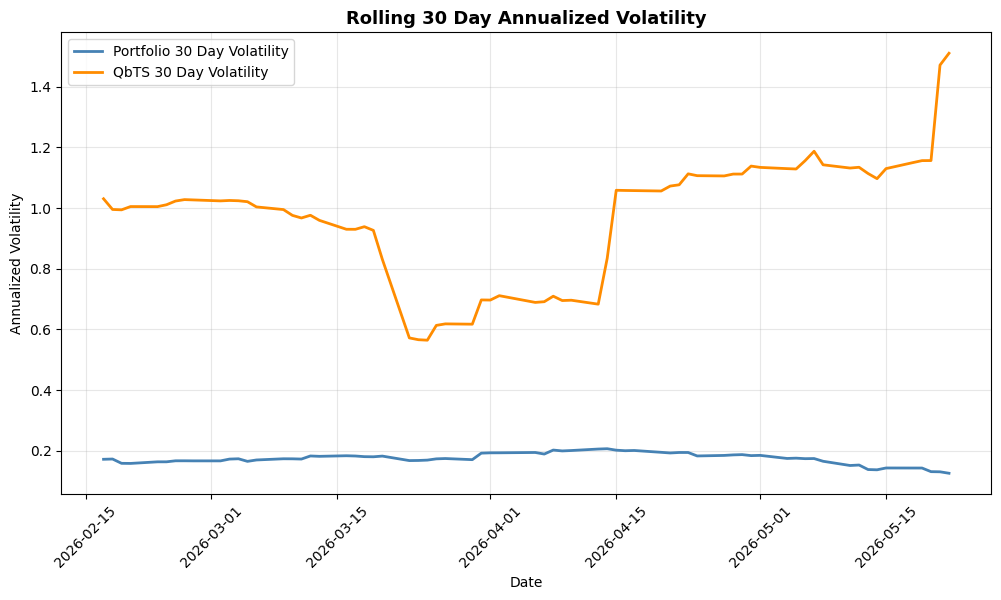

In [67]:
# Rolling 30 Day Volatility Comparison
rolling_volatility_portfolio = portfolio_daily_return.rolling(window =30).std() * np.sqrt(252)
rolling_volatility_qbts = return_qbts.rolling(window = 30).std() * np.sqrt(252)

plt.figure(figsize = (12, 6))
plt.plot(rolling_volatility_portfolio.index,
         rolling_volatility_portfolio.values,
         label = 'Portfolio 30 Day Volatility',
         color = 'steelblue',
         linewidth = 2)

plt.plot(rolling_volatility_qbts.index,
         rolling_volatility_qbts.values,
         label = 'QbTS 30 Day Volatility',
         color = 'darkorange',
         linewidth = 2)

plt.title('Rolling 30 Day Annualized Volatility', fontsize = 13, fontweight = 'bold')
plt.ylabel('Annualized Volatility')
plt.xlabel('Date')
plt.xticks(rotation = 45)
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()